Enter 1 for demand Excel or 2 for distribution Excel: 2


Saving milkdist.xlsx to milkdist.xlsx
Enter number of simulation days: 120

===== NEW POLICY (GA Optimized) =====
 day  MILK_A_demand  MILK_A_served  MILK_A_lost_sales  MILK_B_demand  MILK_B_served  MILK_B_lost_sales  MILK_C_demand  MILK_C_served  MILK_C_lost_sales  MILK_A_expired  MILK_A_profit  MILK_A_loss  MILK_B_expired  MILK_B_profit  MILK_B_loss  MILK_C_expired  MILK_C_profit  MILK_C_loss  total_profit  MILK_A_inventory_on_hand  MILK_A_pipeline  MILK_A_order_placed  MILK_B_inventory_on_hand  MILK_B_pipeline  MILK_B_order_placed  MILK_C_inventory_on_hand  MILK_C_pipeline  MILK_C_order_placed
   1            145            145                  0             74             74                  0             23             23                  0               0            145            0               0             74            0               0             23            0           242                        60                0                  145                         5         

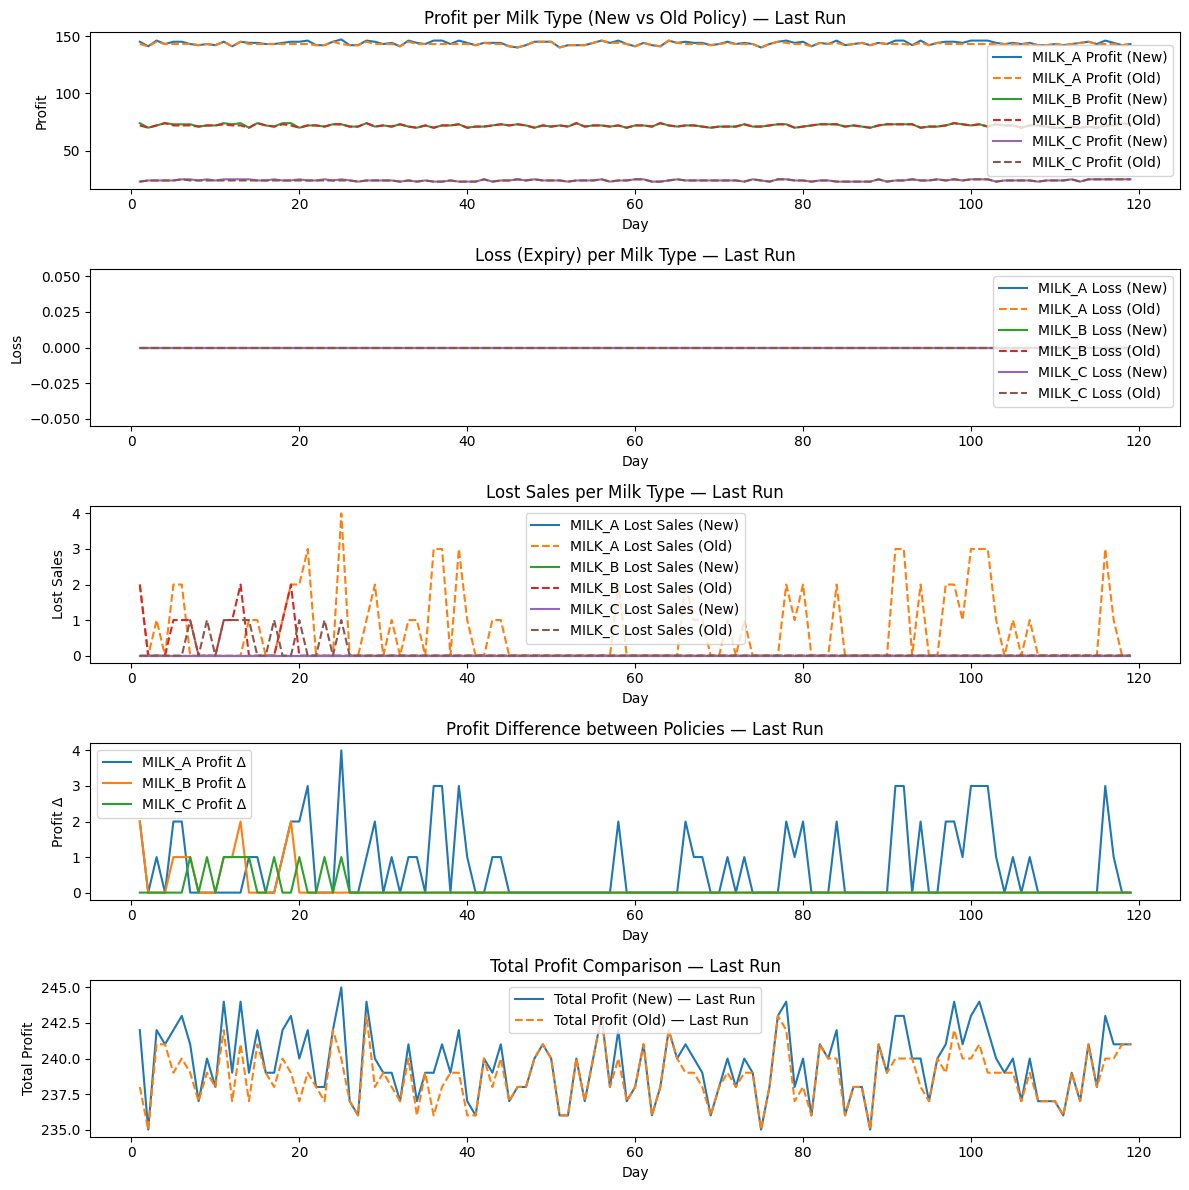

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from google.colab import files
from scipy.stats import ttest_ind
import copy
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from scipy.stats import jarque_bera, ttest_rel, wilcoxon

# ------------------- INPUT -------------------
option = int(input("Enter 1 for demand Excel or 2 for distribution Excel: "))
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ------------------- PARAMETERS -------------------
sku_list = ["MILK_A", "MILK_B", "MILK_C"]
lead_time = {"MILK_A": 1, "MILK_B": 1, "MILK_C": 1}
shelf_life = {"MILK_A": 2, "MILK_B": 2, "MILK_C": 2}
cost_price = {"MILK_A": 28, "MILK_B": 24, "MILK_C": 11}
sell_price = {"MILK_A": 29, "MILK_B": 25, "MILK_C": 12}

best_fit = {}
demand_mean = {}

# ------------------- EXCEL OPTION 1 -------------------
if option == 1:
    demand_df = pd.read_excel(filename)
    for sku in sku_list:
        demand_df[sku] = pd.to_numeric(demand_df[sku], errors='coerce').fillna(0).astype(int)
    demand_df = demand_df[(demand_df[sku_list].sum(axis=1) > 0)].reset_index(drop=True)
    days_total = len(demand_df)
    train_size = int(0.75 * days_total)

    train_df = demand_df.iloc[:train_size][sku_list]
    test_df = demand_df.iloc[train_size:][sku_list]

    # Fit distributions on train data
    for sku in sku_list:
        data = train_df[sku].values
        distributions = [stats.norm, stats.expon, stats.gamma, stats.beta, stats.lognorm, stats.uniform]
        best_sku = None
        best_p = -1
        best_params = None
        for dist in distributions:
            try:
                if dist == stats.beta:
                    scaled = (data - min(data)) / (max(data) - min(data) + 1e-6)
                    params = dist.fit(scaled, floc=0, fscale=1)
                    ks_stat, p = stats.kstest(scaled, dist.name, args=params)
                else:
                    params = dist.fit(data)
                    ks_stat, p = stats.kstest(data, dist.name, args=params)
                if p > best_p:
                    best_p = p
                    best_sku = dist.name
                    best_params = params
            except:
                continue
        best_fit[sku] = (best_sku, best_params, best_p)

    # demand_profiles_test holds per-day demand dicts (exact values from test_df)
    demand_profiles_test = test_df.to_dict(orient="records")

# ------------------- EXCEL OPTION 2 -------------------
else:
    dist_df = pd.read_excel(filename)
    num_days = int(input("Enter number of simulation days: "))

    demand_mean = {}
    row = dist_df.iloc[0]
    for sku in sku_list:
        dist_name = row[f"{sku}_dist"].strip().lower()
        if dist_name == "triangular":
            a = row[f"{sku}_min"]
            b = row[f"{sku}_mode"]
            c = row[f"{sku}_max"]
            best_fit[sku] = ("triangular", (a, b, c), 1.0)
            demand_mean[sku] = (a + b + c) / 3
        elif dist_name == "uniform":
            a = row[f"{sku}_min"]
            b = row[f"{sku}_max"]
            best_fit[sku] = ("uniform", (a, b - a), 1.0)
            demand_mean[sku] = (a + b) / 2
        else:
            print(f" Warning: Unknown distribution type for {sku}, defaulting to mean 10")
            best_fit[sku] = ("uniform", (5, 5), 1.0)
            demand_mean[sku] = 10

    # demand_profiles_test is placeholder; we'll generate common demand below
    demand_profiles_test = [{} for _ in range(num_days)]

# ------------------- SIMULATION CLASS -------------------
class MilkInventorySim:
    def __init__(self, sku_list, demand_mean, lead_time, shelf_life, cost_price, sell_price, seed=42):
        self.sku_list = sku_list
        self.demand_mean = demand_mean
        self.lead_time = lead_time
        self.shelf_life = shelf_life
        self.cost_price = cost_price
        self.sell_price = sell_price
        self.inventory_cost = 0
        self.rng = random.Random(seed)
        self.reset()
        self.target_multiplier = {sku: 1.0 for sku in sku_list}

    def reset(self):
        self.inventory = {sku: [] for sku in self.sku_list}
        self.pipeline_orders = {sku: [] for sku in self.sku_list}
        self.metrics = []

    def place_order(self, sku, qty, current_day):
        arrival_day = current_day + self.lead_time[sku]
        self.pipeline_orders[sku].append((arrival_day, qty))

    def step_day(self, day, demand_by_sku=None, auto_place_orders=True, opt=1):
        row = {"day": day}

        # Receive arrivals
        for sku in self.sku_list:
            arrivals = [q for (arrive, q) in self.pipeline_orders[sku] if arrive == day]
            self.pipeline_orders[sku] = [(a, q) for (a, q) in self.pipeline_orders[sku] if a != day]
            for q in arrivals:
                self.inventory[sku].append([q, day])

        total_profit = 0

        for sku in self.sku_list:
            # Demand generation (now always taken from demand_by_sku if provided)
            if demand_by_sku is not None and sku in demand_by_sku and demand_by_sku[sku] != {}:
                d_total = demand_by_sku[sku]
            else:
                dist_name, params, _ = best_fit[sku]
                if dist_name == "triangular":
                    a, b, c = params
                    d_total = int(round(random.triangular(a, c, b)))
                elif dist_name == "uniform":
                    a, width = params
                    d_total = int(round(stats.uniform.rvs(a, width)))
                elif dist_name == "norm":
                    d_total = int(round(stats.norm.rvs(*params)))
                elif dist_name == "expon":
                    d_total = int(round(stats.expon.rvs(*params)))
                elif dist_name == "gamma":
                    d_total = int(round(stats.gamma.rvs(*params)))
                elif dist_name == "beta":
                    d_total = int(round(stats.beta.rvs(*params) * 30))
                elif dist_name == "lognorm":
                    d_total = int(round(stats.lognorm.rvs(*params)))
                else:
                    d_total = self.demand_mean[sku]
            d_total = max(0, d_total)
            row[f"{sku}_demand"] = d_total

            # FIFO serving first
            served_total = 0
            need = d_total
            self.inventory[sku].sort(key=lambda x: x[1])  # oldest first
            while need > 0 and self.inventory[sku]:
                qty, arr_day = self.inventory[sku][0]
                take = min(qty, need)
                served_total += take
                need -= take
                if take < qty:
                    self.inventory[sku][0][0] -= take
                else:
                    self.inventory[sku].pop(0)

            lost_sales = d_total - served_total
            row[f"{sku}_served"] = served_total
            row[f"{sku}_lost_sales"] = lost_sales

        # Expiry check after serving demand
        for sku in self.sku_list:
            fresh_batches = []
            expired_qty = 0
            for qty, arr_day in self.inventory[sku]:
                if day - arr_day < self.shelf_life[sku]:
                    fresh_batches.append([qty, arr_day])
                else:
                    expired_qty += qty
            self.inventory[sku] = fresh_batches
            row[f"{sku}_expired"] = expired_qty

            # Profit calculation
            revenue = (self.sell_price[sku] - self.cost_price[sku] - self.inventory_cost) * row[f"{sku}_served"]
            loss_expired = (self.cost_price[sku] + self.inventory_cost) * expired_qty
            profit = revenue - loss_expired

            row[f"{sku}_profit"] = profit
            row[f"{sku}_loss"] = loss_expired
            total_profit += profit

        row["total_profit"] = total_profit

        # Inventory snapshot & ordering
        for sku in self.sku_list:
            on_hand = sum(q for q, _ in self.inventory[sku])
            pipeline = sum(q for _, q in self.pipeline_orders[sku])
            row[f"{sku}_inventory_on_hand"] = on_hand
            row[f"{sku}_pipeline"] = pipeline

            if auto_place_orders:
                multiplier = self.target_multiplier[sku]
                if option == 1:
                    base_target = int(np.mean(train_df[sku]))
                else:
                    base_target = int(self.demand_mean[sku])
                target_level = int(base_target * multiplier)
                pos = row[f"{sku}_inventory_on_hand"] + row[f"{sku}_pipeline"]
                order_qty = max(0, target_level - pos)
                if order_qty > 0:
                    self.place_order(sku, order_qty, day)
                row[f"{sku}_order_placed"] = order_qty
            else:
                row[f"{sku}_order_placed"] = 0

        self.metrics.append(row)

    def run(self, demand_profiles, auto_place_orders=True, opt=1, warmup_days=0):
        self.metrics = []  # RESET metrics at start
        days = len(demand_profiles)
        for d in range(1, days + 1):
            profile = demand_profiles[d - 1]
            self.step_day(d, demand_by_sku=profile, auto_place_orders=auto_place_orders, opt=opt)
        if warmup_days > 0:
            return pd.DataFrame(self.metrics[warmup_days:]).reset_index(drop=True)
        return pd.DataFrame(self.metrics)

# ------------------- GA OPTIMIZATION -------------------
def optimize_multipliers(sim, demand_profiles, generations=20, population_size=10):
    # NOTE: changed to return the multipliers dict (no per-run prints)
    best_individual = [1.0] * len(sku_list)
    best_profit = -1e9
    for gen in range(generations):
        population = np.random.uniform(0.5, 2.0, (population_size, len(sku_list)))
        for individual in population:
            sim.reset()  # RESET inventory and metrics before each simulation
            sim.target_multiplier = {sku_list[i]: individual[i] for i in range(len(sku_list))}
            df = sim.run(demand_profiles, auto_place_orders=True)
            total = df["total_profit"].sum()
            if total > best_profit:
                best_profit = total
                best_individual = individual.copy()
    sim.reset()  # RESET before final run
    sim.target_multiplier = {sku_list[i]: best_individual[i] for i in range(len(sku_list))}
    # return multipliers for external handling (we'll average them across runs)
    return {sku_list[i]: sim.target_multiplier[sku_list[i]] for i in range(len(sku_list))}

# ------------------- MULTI-RUN EXECUTION -------------------
runs = 10
results_new_runs = []   # store df_new per run
results_old_runs = []   # store df_old per run
multipliers_runs = []   # store multipliers (dict) per run
total_profits_new_runs = []
total_profits_old_runs = []

for run in range(runs):
    # Build common demand for this run (same for both policies)
    if option == 1:
        demand_common = [dict(x) for x in demand_profiles_test]
    else:
        rng = np.random.default_rng(12345 + run)
        demand_common = []
        for day_idx in range(len(demand_profiles_test)):
            row = {}
            for sku in sku_list:
                dist_name, params, _ = best_fit[sku]
                if dist_name == "triangular":
                    a, b, c = params
                    val = float(random.triangular(a, c, b))
                    row[sku] = int(round(val))
                elif dist_name == "uniform":
                    a, width = params
                    val = stats.uniform.rvs(a, width)
                    row[sku] = int(round(val))
                elif dist_name == "norm":
                    val = stats.norm.rvs(*params)
                    row[sku] = int(round(val))
                elif dist_name == "expon":
                    val = stats.expon.rvs(*params)
                    row[sku] = int(round(val))
                elif dist_name == "gamma":
                    val = stats.gamma.rvs(*params)
                    row[sku] = int(round(val))
                elif dist_name == "beta":
                    val = stats.beta.rvs(*params) * 30
                    row[sku] = int(round(val))
                elif dist_name == "lognorm":
                    val = stats.lognorm.rvs(*params)
                    row[sku] = int(round(val))
                else:
                    row[sku] = int(demand_mean.get(sku, 10))
            demand_common.append(row)

    # ------------------- RUN NEW (GA) POLICY using demand_common -------------------
    sim = MilkInventorySim(sku_list, demand_mean, lead_time, shelf_life, cost_price, sell_price)

    if option == 1:
        # Run GA first and capture multipliers
        multipliers = optimize_multipliers(sim, demand_common)
        multipliers_runs.append(multipliers)

        # Initialize inventory for Day1 based on optimized multipliers (same as original)
        for sku in sku_list:
            base_target = int(np.mean(train_df[sku]))
            target_level = int(base_target * multipliers[sku])
            sim.inventory[sku].append([target_level, 0])  # Day1 starts with inventory

        # Run simulation (no warmup)
        df_new = sim.run(demand_common, auto_place_orders=True)

    else:
        # Option 2 warm-up day (same as original)
        for sku in sku_list:
            target_level = int(demand_mean[sku])
            sim.inventory[sku].append([target_level, 0])
        multipliers = optimize_multipliers(sim, demand_common)
        multipliers_runs.append(multipliers)
        df_new = sim.run(demand_common, auto_place_orders=True, warmup_days=1)

    # Save the initial inventory snapshot used for fairness (deep copy)
    initial_inventory_snapshot = {sku: [list(b) for b in sim.inventory[sku]] for sku in sku_list}

    # ------------------- RUN OLD POLICY (order = expected demand every day) on the SAME demand_common -------------------
    sim_old = MilkInventorySim(sku_list, demand_mean, lead_time, shelf_life, cost_price, sell_price)

    # Set initial inventory SAME as new policy started with
    for sku in sku_list:
        sim_old.inventory[sku] = [list(b) for b in initial_inventory_snapshot[sku]]
    sim_old.pipeline_orders = {sku: [] for sku in sku_list}
    sim_old.metrics = []

    # Run day-by-day so we can place "order = expected demand" each day (arrives after lead time)
    days = len(demand_common)
    for d in range(1, days + 1):
        profile = demand_common[d - 1]
        # Serve the day (no automatic GA ordering)
        sim_old.step_day(d, demand_by_sku=profile, auto_place_orders=False)

        # After serving, place order equal to expected demand (so it arrives next day)
        for sku in sku_list:
            if option == 1:
                order_qty = int(np.mean(train_df[sku]))
            else:
                order_qty = int(demand_mean[sku])
            sim_old.place_order(sku, order_qty, d)
            # record order placed in the last row (consistent with how metrics recorded)
            sim_old.metrics[-1][f"{sku}_order_placed"] = sim_old.metrics[-1].get(f"{sku}_order_placed", 0) + order_qty

    # Convert to dataframe and handle warmup for option 2 exactly as original
    df_old = pd.DataFrame(sim_old.metrics)
    if option != 1:
        # Skip warmup day 0 as original did (same handling as new)
        df_old = df_old[1:].reset_index(drop=True)
        df_new = df_new.reset_index(drop=True)  # ensure aligned indexing

    # Ensure day numbering aligns (if warmup removed adjust days column)
    # Recompute day column in both frames to be consistent 1..N
    df_new["day"] = range(1, len(df_new) + 1)
    df_old["day"] = range(1, len(df_old) + 1)

    # store run-level results
    results_new_runs.append(df_new.copy())
    results_old_runs.append(df_old.copy())

    # store totals per run for tests
    total_profits_new_runs.append(df_new["total_profit"].mean())
    total_profits_old_runs.append(df_old["total_profit"].mean())
    # ------------------- OUTPUT -------------------
print("\n===== NEW POLICY (GA Optimized) =====")
print(df_new.to_string(index=False))

print("\n===== OLD POLICY (Order = Expected Demand per day) =====")
print(df_old.to_string(index=False))

# ------------------- AGGREGATE / AVERAGE ACROSS RUNS -------------------
# Average multipliers across runs
# multipliers_runs is list of dicts; create DataFrame and average
mult_df = pd.DataFrame(multipliers_runs)
avg_multipliers = mult_df.mean(axis=0).to_dict()

# Average DataFrames across runs (element-wise by row index)
# We assume all df_new/df_old have identical shapes and indexing after warmup trimming.
# Stack and group by index (0..N-1) then take mean
avg_new = pd.concat(results_new_runs).groupby(level=0).mean()
avg_old = pd.concat(results_old_runs).groupby(level=0).mean()

# For printing table and tests, use averaged frames (avg_new, avg_old)
df_new_avg = avg_new.reset_index(drop=True)
df_old_avg = avg_old.reset_index(drop=True)

# ------------------- STATISTICAL TESTS (using run-wise totals) -------------------
total_profits_new = np.array(total_profits_new_runs)
total_profits_old = np.array(total_profits_old_runs)
diff_runs = total_profits_new - total_profits_old

# Jarque–Bera normality on differences
jb_stat, jb_p = jarque_bera(diff_runs)

# Breusch–Pagan: regress new on old across runs
X_bp = sm.add_constant(total_profits_old)
model_bp = sm.OLS(total_profits_new, X_bp).fit()
bp_test = het_breuschpagan(model_bp.resid, X_bp)
bp_p = bp_test[1]

# Choose test
if jb_p > 0.05 and bp_p > 0.05:
    test_name = "Paired t-test"
    stat_val, p_val = ttest_rel(total_profits_new, total_profits_old)
else:
    test_name = "Wilcoxon signed-rank"
    stat_val, p_val = wilcoxon(total_profits_new, total_profits_old)

# Compute average profits and % gain using run-wise totals
avg_new = total_profits_new.mean()
avg_old = total_profits_old.mean()
gain_pct = ((avg_new - avg_old) / avg_old) * 100

# ------------------- OUTPUT -------------------
# Averaged multipliers
print("\n===== AVERAGED OPTIMIZED MULTIPLIERS (across 10 runs) =====")
for sku in sku_list:
    print(f"{sku}: {avg_multipliers.get(sku, 1.0):.4f}")

# Averaged result table (numeric averages across runs)
print("\n===== AVERAGE PROFITS (per day over horizon) =====")
for sku in sku_list:
    print(f"{sku}: New={df_new_avg[f'{sku}_profit'].mean():.2f}, Old={df_old_avg[f'{sku}_profit'].mean():.2f}")
print(f"TOTAL: New={avg_new:.2f}, Old={avg_old:.2f}")

# Tests summary
print("\n===== AUTOMATED PROFIT COMPARISON (10-run averaged test) =====")
print(f"Normality (Jarque–Bera): p = {jb_p:.4f}")
print(f"Homoskedasticity (Breusch–Pagan): p = {bp_p:.4f}")
print(f"Selected Test: {test_name}")
print(f"Test statistic = {stat_val:.4f}, p-value = {p_val:.6f}")
print(f"Percentage Gain = {gain_pct:.2f}%")
if gain_pct >= 5 and p_val < 0.05:
    print("New policy is statistically and economically superior (>5% gain).")
elif p_val < 0.05:
    print("Statistically different, but <5% gain — not meaningfully better.")
else:
    print("No significant difference — policies perform equivalently.")

# ------------------- PLOTS -------------------
# The user asked earlier that graphs/table be of last run for visualization.
# If you still want the plots from the last run (rather than averaged plots), use:
df_new_last = results_new_runs[-1].reset_index(drop=True)
df_old_last = results_old_runs[-1].reset_index(drop=True)

plt.figure(figsize=(12, 12))

plt.subplot(5, 1, 1)
for sku in sku_list:
    plt.plot(df_new_last["day"], df_new_last[f"{sku}_profit"], label=f"{sku} Profit (New)")
    plt.plot(df_old_last["day"], df_old_last[f"{sku}_profit"], linestyle="--", label=f"{sku} Profit (Old)")
plt.title("Profit per Milk Type (New vs Old Policy) — Last Run")
plt.xlabel("Day"); plt.ylabel("Profit"); plt.legend()

plt.subplot(5, 1, 2)
for sku in sku_list:
    plt.plot(df_new_last["day"], df_new_last[f"{sku}_loss"], label=f"{sku} Loss (New)")
    plt.plot(df_old_last["day"], df_old_last[f"{sku}_loss"], linestyle="--", label=f"{sku} Loss (Old)")
plt.title("Loss (Expiry) per Milk Type — Last Run")
plt.xlabel("Day"); plt.ylabel("Loss"); plt.legend()

plt.subplot(5, 1, 3)
for sku in sku_list:
    plt.plot(df_new_last["day"], df_new_last[f"{sku}_lost_sales"], label=f"{sku} Lost Sales (New)")
    plt.plot(df_old_last["day"], df_old_last[f"{sku}_lost_sales"], linestyle="--", label=f"{sku} Lost Sales (Old)")
plt.title("Lost Sales per Milk Type — Last Run")
plt.xlabel("Day"); plt.ylabel("Lost Sales"); plt.legend()

plt.subplot(5, 1, 4)
for sku in sku_list:
    plt.plot(df_new_last["day"], df_new_last[f"{sku}_profit"] - df_old_last[f"{sku}_profit"], label=f"{sku} Profit Δ")
plt.title("Profit Difference between Policies — Last Run")
plt.xlabel("Day"); plt.ylabel("Profit Δ"); plt.legend()

plt.subplot(5, 1, 5)
plt.plot(df_new_last["day"], df_new_last["total_profit"], label="Total Profit (New) — Last Run")
plt.plot(df_old_last["day"], df_old_last["total_profit"], linestyle="--", label="Total Profit (Old) — Last Run")
plt.title("Total Profit Comparison — Last Run")
plt.xlabel("Day"); plt.ylabel("Total Profit"); plt.legend()

plt.tight_layout()
plt.show()
